In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import *
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import *

In [14]:
DATASET_PATH = r"F:/Memoire AI/DATA"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 20

In [4]:
benign_path = os.path.join(DATASET_PATH, "0")
malignant_path = os.path.join(DATASET_PATH, "1")

print("0 :", len(os.listdir(benign_path)))
print("1 :", len(os.listdir(malignant_path)))

0 : 2010
1 : 610


In [22]:
benign_files = [os.path.join(benign_path, f) for f in os.listdir(benign_path)]
malignant_files = [os.path.join(malignant_path, f) for f in os.listdir(malignant_path)]

In [23]:
df_benign = pd.DataFrame({
    "filepath": benign_files,
    "label": 0
})

df_malignant = pd.DataFrame({
    "filepath": malignant_files,
    "label": 1
})

In [24]:
df = pd.concat([df_benign, df_malignant], ignore_index=True)

In [25]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
print(df.head())
print(df["label"].value_counts())

                                            filepath  label
0                  F:/Memoire AI/DATA\1\img_2096.png      1
1  F:/Memoire AI/DATA\0\MG-PROC__L_CC2.16.840.1.1...      0
2  F:/Memoire AI/DATA\0\MG-PROC__R_CC2.16.840.1.1...      0
3  F:/Memoire AI/DATA\0\MG-PROC__R_MLO2.16.840.1....      0
4                  F:/Memoire AI/DATA\1\img_2298.png      1
label
0    2010
1     610
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [28]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=5,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.95,1.05]
)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 2096 validated image filenames.


In [29]:
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="raw",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 524 validated image filenames.


In [30]:
neg = len(train_df[train_df["label"] == 0])
pos = len(train_df[train_df["label"] == 1])

class_weight = {
    0: 1.0,
    1: neg / pos
}

print(class_weight)

{0: 1.0, 1: 3.2950819672131146}


In [31]:
base = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dropout(0.5)(x)
out = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=base.input, outputs=out)

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",   # ou focal loss ensuite
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [33]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 632s 5s/step - accuracy: 0.5472 - auc: 0.4653 - loss: 1.3589 - precision: 0.2266 - recall: 0.3914 - val_accuracy: 0.7099 - val_auc: 0.5919 - val_loss: 0.5914 - val_precision: 0.3295 - val_recall: 0.2377 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 628s 5s/step - accuracy: 0.5754 - auc: 0.5957 - loss: 1.1228 - precision: 0.2796 - recall: 0.5225 - val_accuracy: 0.7958 - val_auc: 0.7854 - val_loss: 0.5215 - val_precision: 0.5652 - val_recall: 0.5328 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 457s 3s/step - accuracy: 0.6422 - auc: 0.6901 - loss: 1.0004 - precision: 0.3525 - recall: 0.6414 - val_accuracy: 0.8683 - val_auc: 0.8698 - val_loss: 0.4418 - val_precision: 0.7573 - val_recall: 0.6393 - learning_rate: 1.0000e-04
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 611s 5s/step - accuracy: 0.7156 - auc: 0.7646 - loss: 0.8991 - precision: 0.4306 - recall: 0.6865 - val_accuracy: 0.9027 - val_auc: 0.8952 - val_lo

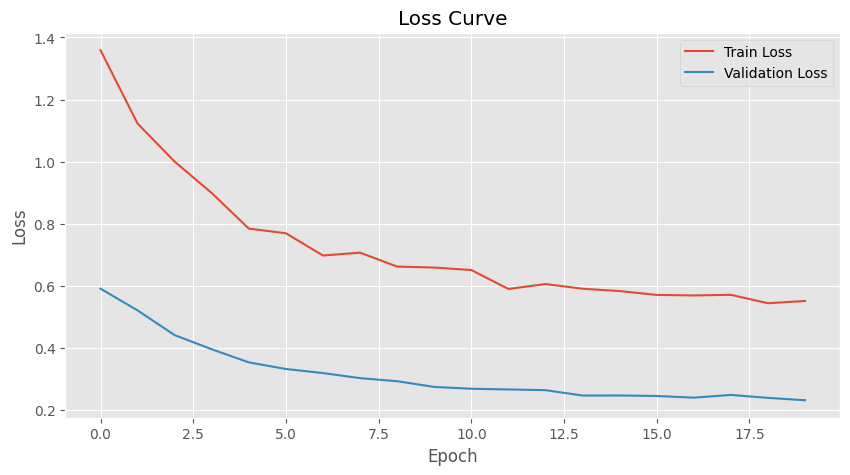

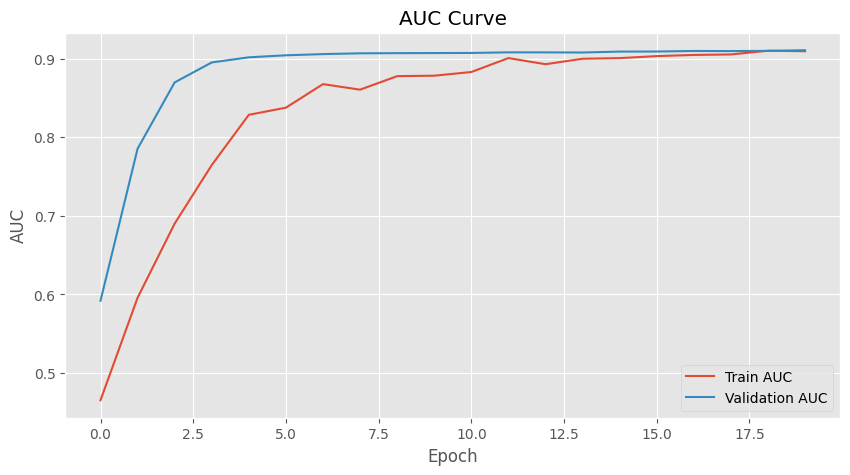

In [35]:
import matplotlib.pyplot as plt

# =========================
# LOSS
# =========================
plt.style.use("ggplot")
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()


# =========================
# AUC
# =========================

plt.figure(figsize=(10,5))

plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')

plt.title('AUC Curve')
plt.xlabel('Epoch')
plt.ylabel('AUC')

plt.legend()

plt.show()

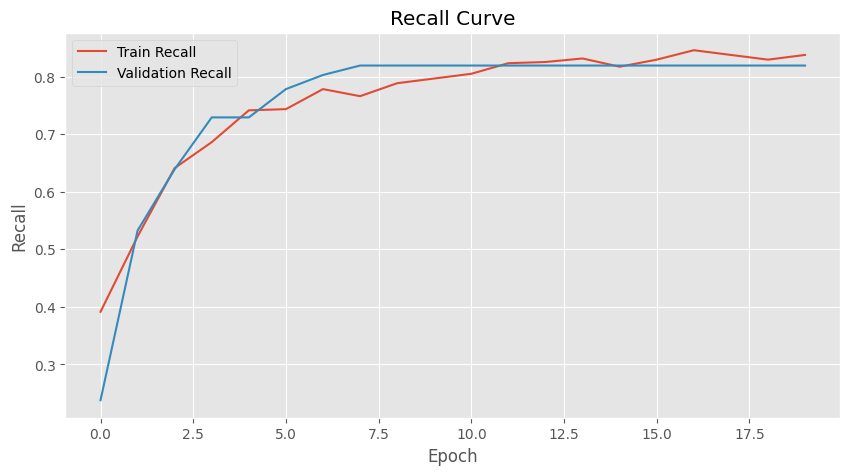

In [36]:
plt.figure(figsize=(10,5))

plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')

plt.title('Recall Curve')
plt.xlabel('Epoch')
plt.ylabel('Recall')

plt.legend()

plt.show()

In [37]:
import pandas as pd

pd.DataFrame(history.history).to_csv("training_history.csv", index=False)

In [41]:
predictions = model.predict(val_generator)

pred_labels = (predictions > 0.5).astype(int)

true_labels = val_generator.labels

33/33 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step


In [42]:
cm = confusion_matrix(true_labels, pred_labels)

print(cm)

[[397   5]
 [ 22 100]]


In [43]:
print(classification_report(true_labels, pred_labels))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       402
           1       0.95      0.82      0.88       122

    accuracy                           0.95       524
   macro avg       0.95      0.90      0.92       524
weighted avg       0.95      0.95      0.95       524



In [44]:
auc = roc_auc_score(true_labels, predictions)

print("AUC :", auc)

AUC : 0.9109167278362287


In [45]:
model.save(r"F:/breast-cancer-mobileNet/model/breast_cancer_mobilenet1.keras")

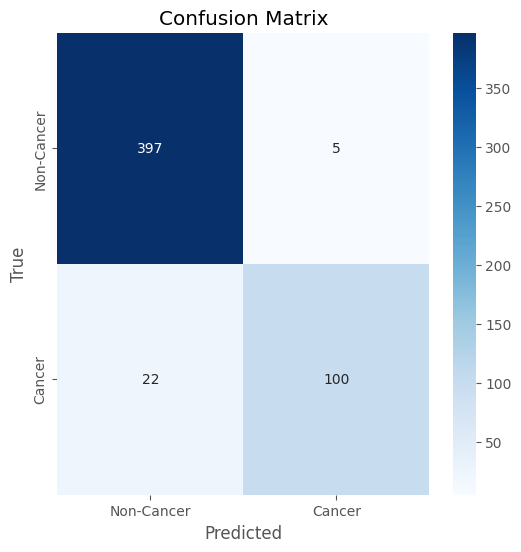

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Non-Cancer", "Cancer"],
    yticklabels=["Non-Cancer", "Cancer"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

In [50]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(true_labels, predictions)

best_idx = np.argmax(tpr - fpr)

best_threshold = thresholds[best_idx]

print("Best threshold :", best_threshold)

Best threshold : 0.6796146


In [51]:
pred_labels = (predictions >= best_threshold).astype(int)

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf

def predict_image(model, img_path, threshold=0.5):

    # =========================
    # LOAD IMAGE
    # =========================
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # =========================
    # PREPROCESS (IMPORTANT MobileNet)
    # =========================
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

    # =========================
    # PREDICTION
    # =========================
    prob = model.predict(img_array)[0][0]

    pred_class = "Cancer" if prob >= threshold else "Non Cancer"

    # =========================
    # DISPLAY
    # =========================
    plt.figure(figsize=(5,5))
    plt.imshow(image.load_img(img_path))
    plt.axis("off")

    plt.title(
        f"Prediction: {pred_class}\nProbabilité Cancer: {prob:.4f}",
        fontsize=12
    )

    plt.show()

    print("=== RESULT ===")
    print("Probability :", prob)
    print("Prediction :", pred_class)

    return prob, pred_class

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


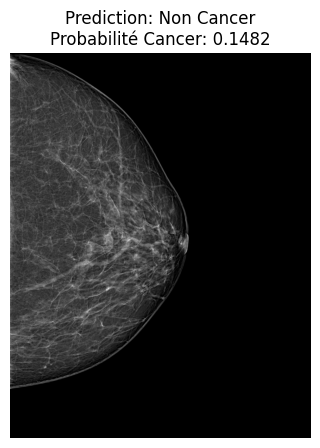

=== RESULT ===
Probability : 0.14820768
Prediction : Non Cancer


(np.float32(0.14820768), 'Non Cancer')

In [56]:
img_path = r"F:/breast-cancer-mobileNet/BC1 (1).png"

predict_image(model, img_path)